In [1]:
import numpy as np
import gstools as gs
import matplotlib.pyplot as plt
from scipy.ndimage import convolve



x=y=z = range(100)
model_1 = gs.Gaussian(dim=3, var=1, len_scale=[2, 2, 2], angles=[0, 0, 0])

model_2 = gs.Gaussian(dim=3, var=1, len_scale=[5, 5, 5], angles=[0, 0, 0])

model_3 = gs.Gaussian(dim=3, var=1, len_scale=[10, 10, 10], angles=[0, 0, 0])

srf_1 = gs.SRF(model_1)
srf_2 = gs.SRF(model_2)
srf_3 = gs.SRF(model_3)

srf_1((x,y,z), mesh_type='structured' , seed=0)
srf_2((x,y,z), mesh_type='structured' , seed=1)
srf_3((x,y,z), mesh_type='structured' , seed=2)

mesh_1 = srf_1.to_pyvista() 
mesh_2 = srf_2.to_pyvista() 
mesh_3 = srf_3.to_pyvista() 

mesh_1.contour(isosurfaces=50).plot()
mesh_2.contour(isosurfaces=50).plot()
mesh_3.contour(isosurfaces=50).plot()


Widget(value='<iframe src="http://localhost:63730/index.html?ui=P_0x1e947ec12b0_0&reconnect=auto" class="pyvis…

Widget(value='<iframe src="http://localhost:63730/index.html?ui=P_0x1e952c60690_1&reconnect=auto" class="pyvis…

Widget(value='<iframe src="http://localhost:63730/index.html?ui=P_0x1e952c62350_2&reconnect=auto" class="pyvis…

In [ ]:
import numpy as np
import gstools as gs
import matplotlib.pyplot as plt
from scipy.ndimage import convolve



x=y = range(100)
model_1_2d = gs.Gaussian(dim=2, var=1, len_scale=[2, 2], angles=[0, 0])

model_2_2d = gs.Gaussian(dim=2, var=1, len_scale=[1, 5], angles=[np.pi/4, np.pi/4])



srf_1_2d = gs.SRF(model_1_2d)
srf_2_2d = gs.SRF(model_2_2d)


srf_1_2d((x,y), mesh_type='structured' , seed=0)
srf_2_2d((x,y), mesh_type='structured' , seed=1)


mesh_1_2d = srf_1_2d.to_pyvista() 
mesh_2_2d = srf_2_2d.to_pyvista() 
 

mesh_1_2d.contour(isosurfaces=50).plot()
mesh_2_2d.contour(isosurfaces=50).plot()

field_1_2d = srf_1_2d.field
field_2_2d = srf_2_2d.field




Widget(value='<iframe src="http://localhost:63730/index.html?ui=P_0x1e9574ddd10_5&reconnect=auto" class="pyvis…

Widget(value='<iframe src="http://localhost:63730/index.html?ui=P_0x1e9574df4d0_6&reconnect=auto" class="pyvis…

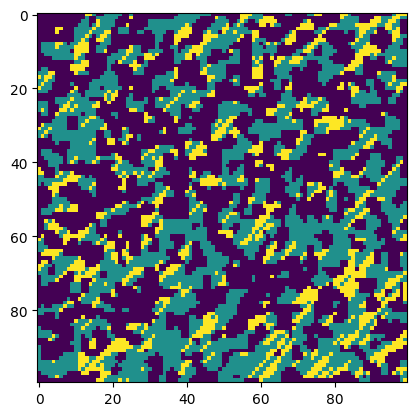

In [3]:
lithotype_map = np.zeros((100, 100))

cut_1 = 0.0
cut_2 = 0.5

lithotype_map[(field_1_2d >= cut_1) & (field_2_2d < cut_2)] = 1

lithotype_map[(field_1_2d >= cut_1) & (field_2_2d >= cut_2)] = 2

plt.imshow(lithotype_map, cmap='viridis')


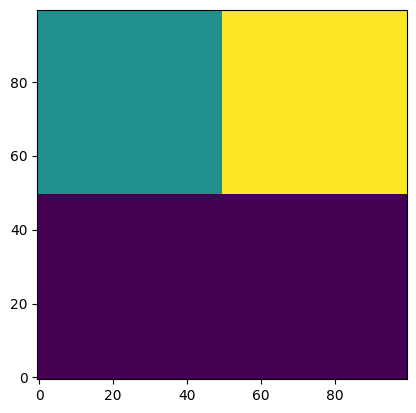

In [4]:
import numpy as np
import matplotlib.pyplot as plt


rule_diagram = np.zeros((100, 100))

rule_diagram[50:100, 0:50] = 1

rule_diagram[50:100, 50:100] = 2

plt.imshow(rule_diagram, origin='lower', cmap='viridis')
plt.show()

Project: Virtual Prototyping of a Deep Geothermal Aquifer (gemini special)
Background & Objective:
To maximize energy extraction and prevent wasted drilling resources, we need to mathematically model the fluid dynamics of a subsurface geothermal reservoir. Before we can run dynamic fluid simulations, we must first construct the static geological environment. This notebook uses Plurigaussian simulation to generate a highly accurate 2D cross-section of the subterranean rock layers based on limited core sample data.

Geological Targets:
Physical testing indicates the reservoir is composed of three distinct lithotypes. Our mathematical model must strictly enforce these real-world volumetric proportions:

Phase 0 (Impermeable Granite Matrix): 65%. This dense rock forms the primary boundary structure and prevents fluid escape.

Phase 1 (Porous Sandstone Channels): 25%. The open, sponge-like network that serves as the main conduit for heated fluids.

Phase 2 (Dense Quartz Inclusions): 10%. Solid, crystalline blocks scattered within the channels that force the fluid to divert and branch.

In [5]:
import numpy as np
import gstools as gs
import matplotlib.pyplot as plt
from scipy.ndimage import convolve
from scipy.stats import norm

granite_percent = 0.65
sandstone_percent = 0.25
quartz_percent = 0.10

cut_1 = norm.ppf(granite_percent)
cut_2 = norm.ppf(sandstone_percent/(quartz_percent + sandstone_percent))

